<a href="https://colab.research.google.com/github/Jaksi-ka/Resume-Screening-System-using-NLP/blob/Fathima/member2_resume_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Unzip the Dataset
!unzip 'archive (5) (1).zip'

Archive:  archive (5) (1).zip
  inflating: Resume/Resume.csv       
  inflating: data/data/ACCOUNTANT/10554236.pdf  
  inflating: data/data/ACCOUNTANT/10674770.pdf  
  inflating: data/data/ACCOUNTANT/11163645.pdf  
  inflating: data/data/ACCOUNTANT/11759079.pdf  
  inflating: data/data/ACCOUNTANT/12065211.pdf  
  inflating: data/data/ACCOUNTANT/12202337.pdf  
  inflating: data/data/ACCOUNTANT/12338274.pdf  
  inflating: data/data/ACCOUNTANT/12442909.pdf  
  inflating: data/data/ACCOUNTANT/12780508.pdf  
  inflating: data/data/ACCOUNTANT/12802330.pdf  
  inflating: data/data/ACCOUNTANT/13072019.pdf  
  inflating: data/data/ACCOUNTANT/13130984.pdf  
  inflating: data/data/ACCOUNTANT/13294301.pdf  
  inflating: data/data/ACCOUNTANT/13491889.pdf  
  inflating: data/data/ACCOUNTANT/13701259.pdf  
  inflating: data/data/ACCOUNTANT/14055988.pdf  
  inflating: data/data/ACCOUNTANT/14126433.pdf  
  inflating: data/data/ACCOUNTANT/14224370.pdf  
  inflating: data/data/ACCOUNTANT/14449423.pdf  
 

In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive (5) (1).zip to archive (5) (1).zip


After uploading the `archive.zip` file, you can then rerun the `!unzip archive.zip` cell (`OXAmX4o_8AYy`) to extract its contents.

In [6]:
# Import Libraries
import pandas as pd
import os

In [9]:
# Read the CSV File
df = pd.read_csv("/content/Resume/Resume.csv")

In [10]:
# View the Dataset
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [11]:
# Check the Column Names
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [12]:
# Chech Dataset Size
print(df.shape)

(2484, 4)


In [13]:
# Check for Missing Values
print(df.isnull().sum())

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [14]:
# Check the categories
for category in df["Category"].unique():
    print(category)

HR
DESIGNER
INFORMATION-TECHNOLOGY
TEACHER
ADVOCATE
BUSINESS-DEVELOPMENT
HEALTHCARE
FITNESS
AGRICULTURE
BPO
SALES
CONSULTANT
DIGITAL-MEDIA
AUTOMOBILE
CHEF
FINANCE
APPAREL
ENGINEERING
ACCOUNTANT
CONSTRUCTION
PUBLIC-RELATIONS
BANKING
ARTS
AVIATION


In [15]:
# Data Exploration - Count of Resumes per Category
print("Total categories:", df["Category"].nunique())
print()
print(df["Category"].value_counts())

Total categories: 24

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [16]:
# Data Exploration - Check for Duplicate Resumes
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate resume texts:", df["Resume_str"].duplicated().sum())

Duplicate rows: 0
Duplicate resume texts: 2


In [17]:
# Text preprocessing
# Install required libraries
!pip install nltk

In [18]:
# Import Libraries
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [19]:
# Download NLTK Data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [20]:
# View One Resume Before Cleaning
print(df["Resume_str"][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [21]:
# Create Stopwords & Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [22]:
# Create the Cleaning Function

def clean_resume(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [23]:
# Apply Cleaning to Every Resume
df["Cleaned_Resume"] = df["Resume_str"].apply(clean_resume)

In [24]:
# Compare Before & After
print("Original Resume:\n")
print(df["Resume_str"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["Cleaned_Resume"][0])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [25]:
# View the Updated Dataset
df.head()

,ID,Resume_str,Resume_html,Category,Cleaned_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administratormarketing associate hr adminis...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist u hr operation summary versatile...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary year experience recruiting...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlight hr skill hr departm...


In [26]:
# Check Missing Values Again
print(df.isnull().sum())

ID                0
Resume_str        0
Resume_html       0
Category          0
Cleaned_Resume    0
dtype: int64


In [27]:
# Keep Only the Required Columns
cleaned_df = df[["Cleaned_Resume", "Category"]]

In [28]:
# View the Final Dataset
cleaned_df.head()

,Cleaned_Resume,Category
0,hr administratormarketing associate hr adminis...,HR
1,hr specialist u hr operation summary versatile...,HR
2,hr director summary year experience recruiting...,HR
3,hr specialist summary dedicated driven dynamic...,HR
4,hr manager skill highlight hr skill hr departm...,HR


In [29]:
# Save the Cleaned Dataset
cleaned_df.to_csv("cleaned_resume.csv", index=False)

In [30]:
# Download the Cleaned Dataset
from google.colab import files

files.download("cleaned_resume.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

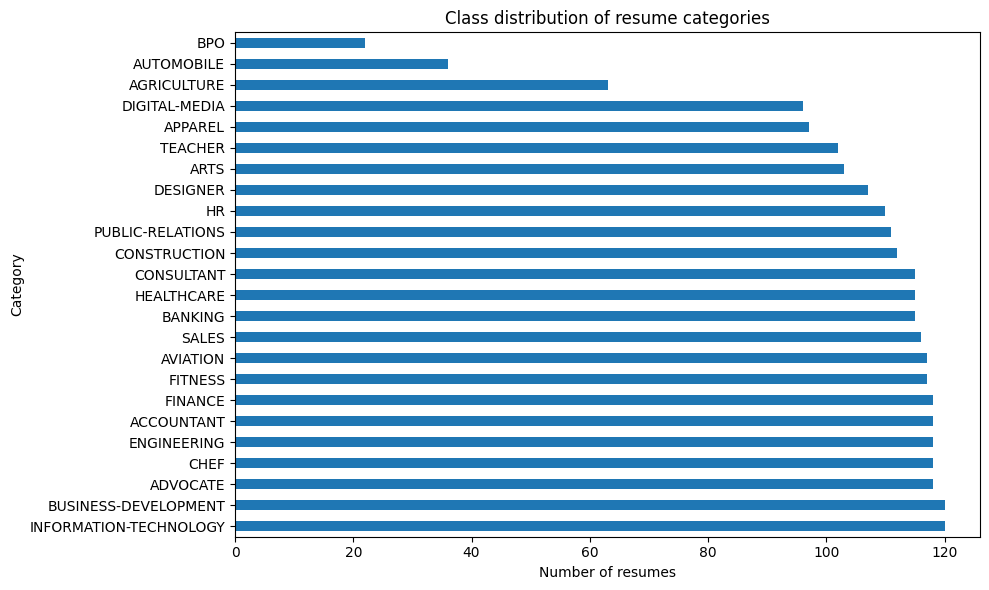

In [31]:
# Exploratory Data Analysis (EDA)
# Visualize the Distribution of Resume Categories

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
df['Category'].value_counts().plot(kind='barh')
plt.title('Class distribution of resume categories')
plt.xlabel('Number of resumes')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

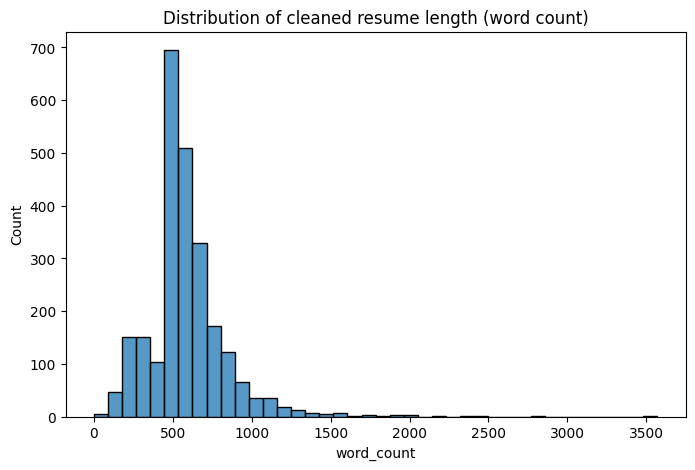

count    2484.000000
mean      586.855475
std       262.343683
min         0.000000
25%       477.000000
50%       547.500000
75%       678.000000
max      3571.000000
Name: word_count, dtype: float64


In [32]:
# Analyze the Distribution of Resume Lengths

df['word_count'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=40)
plt.title('Distribution of cleaned resume length (word count)')
plt.savefig('length_distribution.png')
plt.show()
print(df['word_count'].describe())

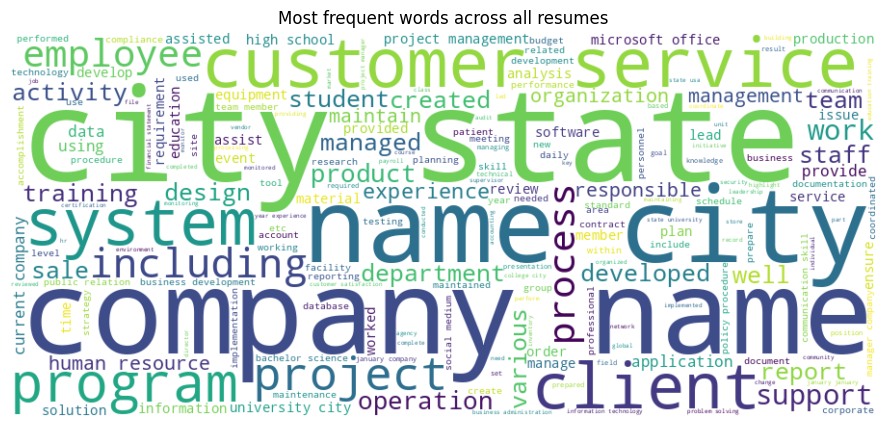

In [33]:
# Generate a Word Cloud of Resume Text

!pip install -q wordcloud
from wordcloud import WordCloud

text_blob = ' '.join(df['Cleaned_Resume'].tolist())
wc = WordCloud(width=900, height=400, background_color='white').generate(text_blob)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words across all resumes')
plt.savefig('wordcloud.png')
plt.show()

In [34]:
# Encode Resume Categories into Numerical Labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])
num_classes = len(le.classes_)
print('Number of classes:', num_classes)
print(dict(zip(le.classes_, le.transform(le.classes_))))

Number of classes: 24
{'ACCOUNTANT': np.int64(0), 'ADVOCATE': np.int64(1), 'AGRICULTURE': np.int64(2), 'APPAREL': np.int64(3), 'ARTS': np.int64(4), 'AUTOMOBILE': np.int64(5), 'AVIATION': np.int64(6), 'BANKING': np.int64(7), 'BPO': np.int64(8), 'BUSINESS-DEVELOPMENT': np.int64(9), 'CHEF': np.int64(10), 'CONSTRUCTION': np.int64(11), 'CONSULTANT': np.int64(12), 'DESIGNER': np.int64(13), 'DIGITAL-MEDIA': np.int64(14), 'ENGINEERING': np.int64(15), 'FINANCE': np.int64(16), 'FITNESS': np.int64(17), 'HEALTHCARE': np.int64(18), 'HR': np.int64(19), 'INFORMATION-TECHNOLOGY': np.int64(20), 'PUBLIC-RELATIONS': np.int64(21), 'SALES': np.int64(22), 'TEACHER': np.int64(23)}


In [35]:
# Split the Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Cleaned_Resume'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
print('Train size:', len(X_train_text), '| Test size:', len(X_test_text))

Train size: 1987 | Test size: 497


In [36]:
# Extract TF-IDF Features from Resume Text

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print('TF-IDF matrix shape:', X_train_tfidf.shape)

TF-IDF matrix shape: (1987, 5000)


In [37]:
# Train the Baseline Random Forest Model

from sklearn.ensemble import RandomForestClassifier
import time

rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
start = time.time()
rf_baseline.fit(X_train_tfidf, y_train)
print(f'Random Forest training time: {time.time()-start:.2f} seconds')

Random Forest training time: 17.70 seconds


In [38]:
# Evaluate the Baseline Random Forest Model

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

y_pred_base = rf_baseline.predict(X_test_tfidf)
acc_base = accuracy_score(y_test, y_pred_base)
print(f'Baseline Random Forest -> Accuracy: {acc_base:.4f}')

Baseline Random Forest -> Accuracy: 0.7646


In [39]:
# Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 50],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)

start = time.time()
grid.fit(X_train_tfidf, y_train)
print(f'\nTuning time: {time.time()-start:.2f} seconds')
print('Best parameters:', grid.best_params_)
print('Best cross-validation F1 score:', round(grid.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Tuning time: 279.47 seconds
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1 score: 0.7079


In [40]:
# Select the Best Random Forest Model

rf_model = grid.best_estimator_
rf_model

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [41]:
# Evaluate the Performance of the Tuned Random Forest Model

y_pred_rf = rf_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred_rf)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')
print(f'Random Forest -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest -> Accuracy: 0.7646 | Precision: 0.7830 | Recall: 0.7646 | F1: 0.7479

                        precision    recall  f1-score   support

            ACCOUNTANT       0.68      0.96      0.79        24
              ADVOCATE       0.89      0.71      0.79        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       1.00      0.42      0.59        19
                  ARTS       0.62      0.24      0.34        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.80      0.83      0.82        24
               BANKING       0.75      0.65      0.70        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.79      0.92      0.85        24
                  CHEF       0.90      0.75      0.82        24
          CONSTRUCTION       0.91      0.95      0.93        22
            CONSULTANT       0.82      0.61      0.70        23
              DESI

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [42]:
# Compare Baseline vs Tuned Random Forest

print(f'Baseline accuracy : {acc_base:.4f}')
print(f'Tuned accuracy    : {acc:.4f}')
print(f'Improvement       : {(acc - acc_base)*100:.2f}%')

Baseline accuracy : 0.7646
Tuned accuracy    : 0.7646
Improvement       : 0.00%


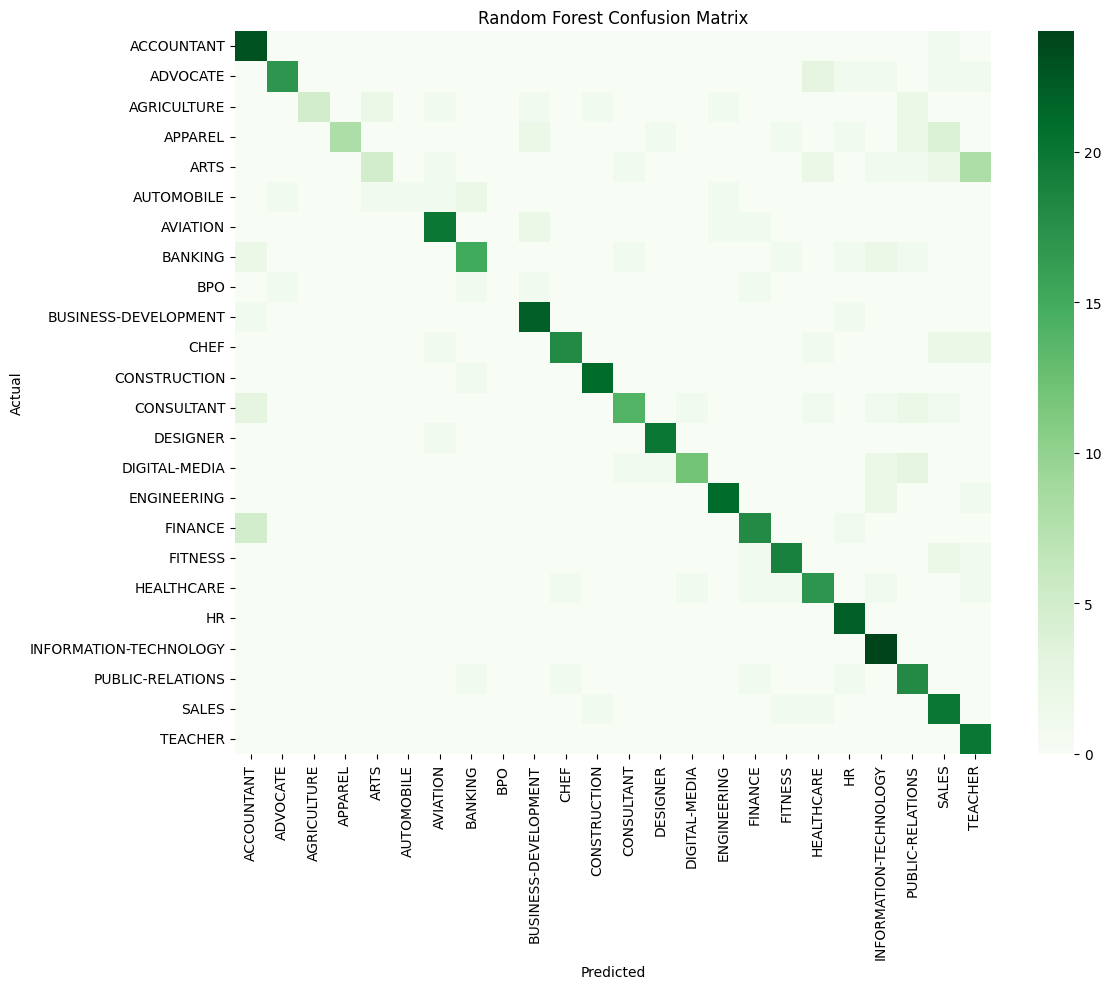

In [43]:
# Visualize the Random Forest Confusion Matrix

plt.figure(figsize=(12,10))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png')
plt.show()

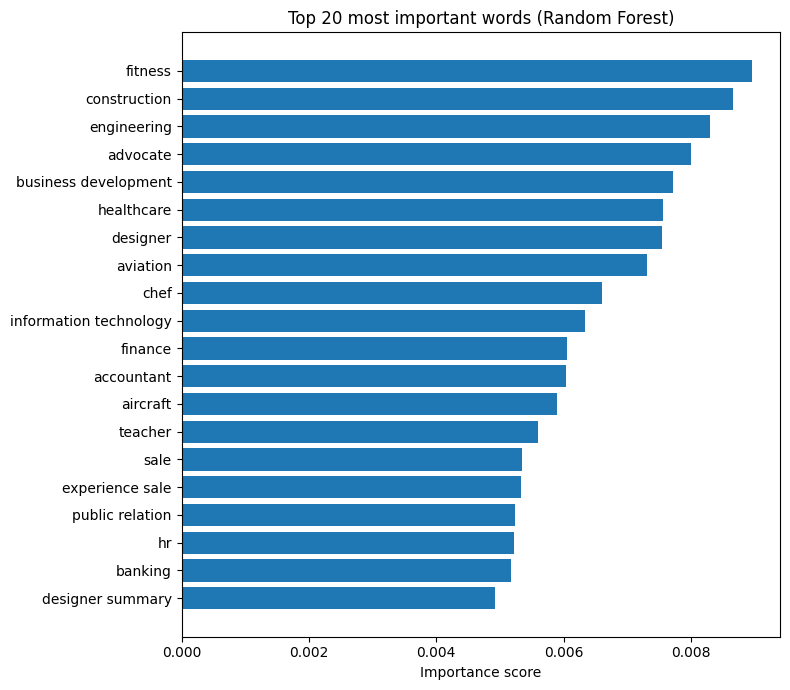

In [44]:
# View the Most Important Features Learned by Random Forest

import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
importances = rf_model.feature_importances_
top_idx = importances.argsort()[-20:]

plt.figure(figsize=(8,7))
plt.barh(feature_names[top_idx], importances[top_idx])
plt.title('Top 20 most important words (Random Forest)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

In [45]:
# Enable GPU and Import Libraries for Bi-LSTM

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [46]:
# Tokenize the Resume Text and Convert to Sequences

MAX_WORDS = 20000
MAX_LEN = 300

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train_text)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = keras_tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('Vocabulary size:', len(keras_tokenizer.word_index))
print('Padded training shape:', X_train_pad.shape)

Vocabulary size: 39647
Padded training shape: (1987, 300)


In [47]:
# One-Hot Encode the Labels for the Bi-LSTM

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)
print('Label shape:', y_train_cat.shape)

Label shape: (1987, 24)


In [48]:
# Build the Bi-LSTM Model

EMBED_DIM = 128

bilstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Train the Bi-LSTM Model

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = bilstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.0617 - loss: 3.1620 - val_accuracy: 0.1106 - val_loss: 3.1295
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1372 - loss: 2.9118 - val_accuracy: 0.2362 - val_loss: 2.7034
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3153 - loss: 2.3601 - val_accuracy: 0.3518 - val_loss: 2.2688
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.4619 - loss: 1.8947 - val_accuracy: 0.5025 - val_loss: 1.9233
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5714 - loss: 1.4729 - val_accuracy: 0.5251 - val_loss: 1.7100
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6583 - loss: 1.1856 - val_accuracy: 0.5578 - val_loss: 1.6445
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7256 - loss: 0.9449 - val_accuracy: 0.5704 - val_loss: 1.6071
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7502 - loss: 0.8257 - val_accuracy: 0.5829 - 

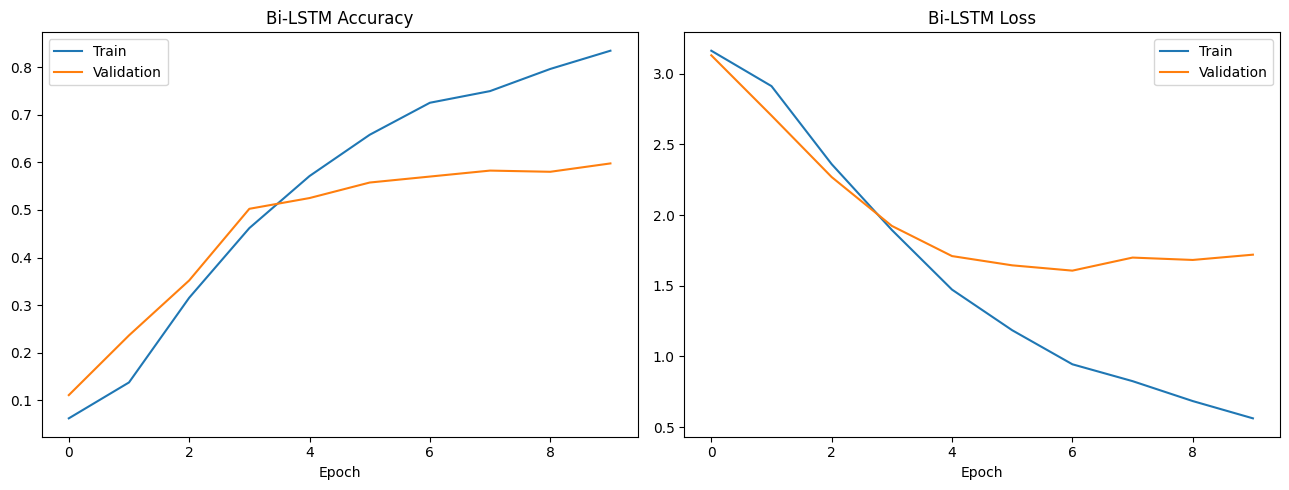

In [50]:
# Plot the Training and Validation Curves

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Bi-LSTM Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Bi-LSTM Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('bilstm_training_curves.png')
plt.show()

In [51]:
# Evaluate the Bi-LSTM Model

y_prob_bilstm = bilstm_model.predict(X_test_pad)
y_pred_bilstm = y_prob_bilstm.argmax(axis=1)

acc_bilstm = accuracy_score(y_test, y_pred_bilstm)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_test, y_pred_bilstm, average='weighted')
print(f'Bi-LSTM -> Accuracy: {acc_bilstm:.4f} | Precision: {prec_b:.4f} | Recall: {rec_b:.4f} | F1: {f1_b:.4f}')
print()
print(classification_report(y_test, y_pred_bilstm, target_names=le.classes_))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Bi-LSTM -> Accuracy: 0.6237 | Precision: 0.6130 | Recall: 0.6237 | F1: 0.6029

                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      0.96      0.96        24
              ADVOCATE       0.79      0.62      0.70        24
           AGRICULTURE       0.00      0.00      0.00        13
               APPAREL       0.22      0.11      0.14        19
                  ARTS       0.29      0.10      0.14        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.40      0.17      0.24        24
               BANKING       0.30      0.52      0.38        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.80      1.00      0.89        24
                  CHEF       0.95      0.75      0.84        24
          CONSTRUCTION       0.90      0.86      0.88        22
            CONSULTANT       0.78      0.91     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

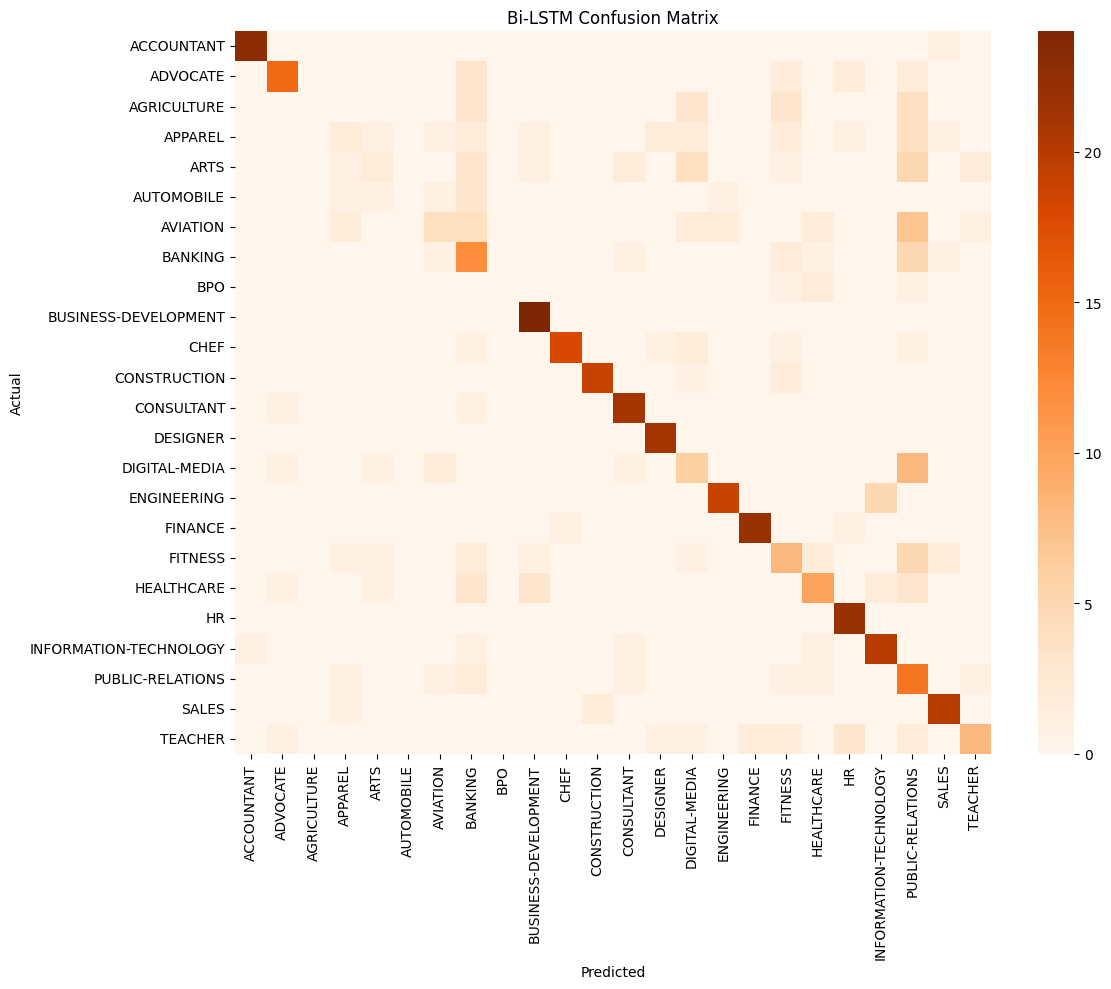

In [52]:
# Visualize the Bi-LSTM Confusion Matrix

plt.figure(figsize=(12,10))
cm_b = confusion_matrix(y_test, y_pred_bilstm)
sns.heatmap(cm_b, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Oranges')
plt.title('Bi-LSTM Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('bilstm_confusion_matrix.png')
plt.show()

In [53]:
# Compare the Performance of Random Forest and Bi-LSTM Models

comparison = pd.DataFrame({
    'Model': ['Random Forest (ML)', 'Bi-LSTM (DL)'],
    'Accuracy': [acc, acc_bilstm],
    'Precision': [prec, prec_b],
    'Recall': [rec, rec_b],
    'F1-score': [f1, f1_b]
})
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest (ML),0.764588,0.783007,0.764588,0.747932
1,Bi-LSTM (DL),0.623742,0.613007,0.623742,0.602873


In [54]:
comparison_pct = comparison.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    comparison_pct[col] = (comparison_pct[col] * 100).round(2).astype(str) + '%'
comparison_pct

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest (ML),76.46%,78.3%,76.46%,74.79%
1,Bi-LSTM (DL),62.37%,61.3%,62.37%,60.29%


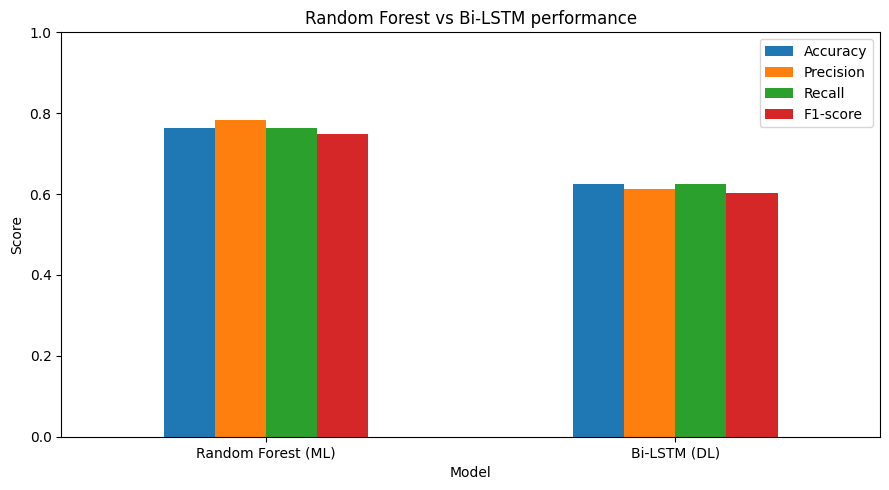

In [55]:
# Visualize the Model Comparison

comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(9,5), ylim=(0,1)
)
plt.title('Random Forest vs Bi-LSTM performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [56]:
# Save the Trained Models and Output Files

import joblib, os, pickle
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model, 'models/random_forest_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

bilstm_model.save('models/bilstm_resume_classifier.keras')
with open('models/keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)

!zip -r member2_outputs.zip models class_distribution.png length_distribution.png wordcloud.png rf_confusion_matrix.png rf_feature_importance.png bilstm_training_curves.png bilstm_confusion_matrix.png model_comparison.png
from google.colab import files
files.download('member2_outputs.zip')

  adding: models/ (stored 0%)
  adding: models/tfidf_vectorizer.pkl (deflated 71%)
  adding: models/bilstm_resume_classifier.keras (deflated 19%)
  adding: models/keras_tokenizer.pkl (deflated 54%)
  adding: models/label_encoder.pkl (deflated 32%)
  adding: models/random_forest_model.pkl (deflated 89%)
  adding: class_distribution.png (deflated 18%)
  adding: length_distribution.png (deflated 20%)
  adding: wordcloud.png (deflated 1%)
  adding: rf_confusion_matrix.png (deflated 17%)
  adding: rf_feature_importance.png (deflated 18%)
  adding: bilstm_training_curves.png (deflated 7%)
  adding: bilstm_confusion_matrix.png (deflated 17%)
  adding: model_comparison.png (deflated 21%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>